In [1]:
!nvcc --version
!pip install nvcc4jupyter
%load_ext nvcc4jupyter

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmpkbi1rvwu".


In [2]:
# Скрипт для запуска CUDA программы на T4 в Google Colab

# 1. Проверка доступного GPU
!nvidia-smi
print("\n" + "="*60)

# 2. Установка правильной версии CUDA Toolkit для T4
!apt-get update
!wget https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2004/x86_64/cuda-keyring_1.0-1_all.deb
!dpkg -i cuda-keyring_1.0-1_all.deb
!apt-get update
!apt-get -y install cuda-toolkit-11-8

# 3. Настройка переменных окружения
import os
os.environ['PATH'] = '/usr/local/cuda-11.8/bin:' + os.environ['PATH']
os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda-11.8/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')

# 4. Проверка установки
!nvcc --version
print("\n" + "="*60)

Tue Jun  2 19:33:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [11]:
%%writefile matmul.cu
#include <iostream>
#include <vector>
#include <chrono>
#include <cmath>
#include <cuda_runtime.h>

#define CUDA_CHECK(call) \
    do { \
        cudaError_t err = call; \
        if (err != cudaSuccess) { \
            std::cerr << "CUDA error: " << cudaGetErrorString(err) << std::endl; \
            exit(EXIT_FAILURE); \
        } \
    } while(0)

// CPU
void matMulCPU(const float* A, const float* B, float* C, int N) {
    for (int i = 0; i < N; ++i) {
        for (int j = 0; j < N; ++j) {
            float sum = 0;
            for (int k = 0; k < N; ++k) {
                sum += A[i * N + k] * B[k * N + j];
            }
            C[i * N + j] = sum;
        }
    }
}

// GPU kernel
__global__ void matMulKernel(const float* A, const float* B, float* C, int N) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if (row < N && col < N) {
        float sum = 0;
        for (int k = 0; k < N; ++k) {
            sum += A[row * N + k] * B[k * N + col];
        }
        C[row * N + col] = sum;
    }
}

// Проверка результатов
bool verify(const float* cpu, const float* gpu, int N, float eps = 1e-2f) {
    for (int i = 0; i < N * N; ++i) {
        if (std::abs(cpu[i] - gpu[i]) > eps) return false;
    }
    return true;
}

int main(int argc, char* argv[]) {
    if (argc != 2) {
        std::cerr << "Usage: " << argv[0] << " <matrix_size>" << std::endl;
        return 1;
    }

    int N = std::atoi(argv[1]);
    size_t bytes = N * N * sizeof(float);

    // Хост-память
    std::vector<float> h_A(N * N), h_B(N * N), h_C_cpu(N * N), h_C_gpu(N * N);

    // Инициализация
    for (int i = 0; i < N * N; ++i) {
        h_A[i] = static_cast<float>(rand()) / RAND_MAX;
        h_B[i] = static_cast<float>(rand()) / RAND_MAX;
    }

    // --- CPU ---
    auto t0 = std::chrono::high_resolution_clock::now();
    matMulCPU(h_A.data(), h_B.data(), h_C_cpu.data(), N);
    auto t1 = std::chrono::high_resolution_clock::now();
    double cpu_ms = std::chrono::duration<double, std::milli>(t1 - t0).count();

    // --- GPU ---
    float *d_A, *d_B, *d_C;
    CUDA_CHECK(cudaMalloc(&d_A, bytes));
    CUDA_CHECK(cudaMalloc(&d_B, bytes));
    CUDA_CHECK(cudaMalloc(&d_C, bytes));

    CUDA_CHECK(cudaMemcpy(d_A, h_A.data(), bytes, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_B, h_B.data(), bytes, cudaMemcpyHostToDevice));

    dim3 block(16, 16);
    dim3 grid((N + 15) / 16, (N + 15) / 16);

    cudaEvent_t start, stop;
    CUDA_CHECK(cudaEventCreate(&start));
    CUDA_CHECK(cudaEventCreate(&stop));

    CUDA_CHECK(cudaEventRecord(start));
    matMulKernel<<<grid, block>>>(d_A, d_B, d_C, N);
    CUDA_CHECK(cudaEventRecord(stop));
    CUDA_CHECK(cudaEventSynchronize(stop));

    float gpu_ms = 0;
    CUDA_CHECK(cudaEventElapsedTime(&gpu_ms, start, stop));

    CUDA_CHECK(cudaMemcpy(h_C_gpu.data(), d_C, bytes, cudaMemcpyDeviceToHost));

    // Очистка GPU
    CUDA_CHECK(cudaFree(d_A)); CUDA_CHECK(cudaFree(d_B)); CUDA_CHECK(cudaFree(d_C));
    CUDA_CHECK(cudaEventDestroy(start)); CUDA_CHECK(cudaEventDestroy(stop));

    // Проверка и вывод
    bool ok = verify(h_C_cpu.data(), h_C_gpu.data(), N);
    printf("%d,%.2f,%.2f,%s\n", N, cpu_ms, gpu_ms, ok ? "OK" : "FAIL");

    return 0;
}

Overwriting matmul.cu


In [12]:
!nvcc -O2 -o matmul matmul.cu -lcudart

In [13]:
!./matmul 100

100,1.47,0.22,OK


Запуск экспериментов...
N=100: CPU=1.41ms, GPU=0.24ms, Speedup=5.88x, OK
N=500: CPU=201.92ms, GPU=0.70ms, Speedup=288.46x, OK
N=1000: CPU=1416.14ms, GPU=4.50ms, Speedup=314.70x, OK
N=1500: CPU=9944.72ms, GPU=18.37ms, Speedup=541.36x, OK
N=2000: CPU=69478.69ms, GPU=51.83ms, Speedup=1340.51x, OK


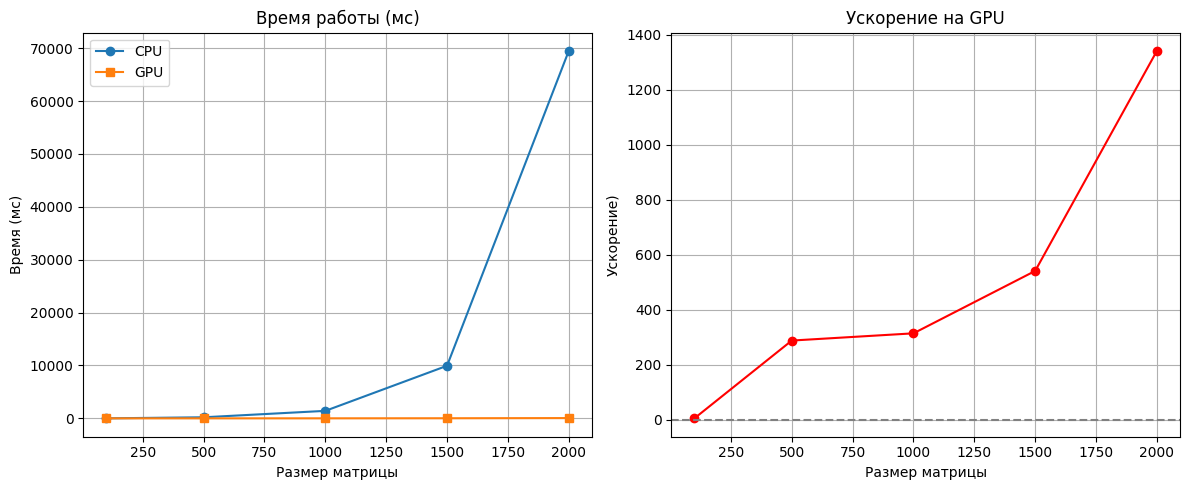


Таблица результатов:
 Size   CPU_ms  GPU_ms     Speedup Status
  100     1.41    0.24    5.875000     OK
  500   201.92    0.70  288.457143     OK
 1000  1416.14    4.50  314.697778     OK
 1500  9944.72   18.37  541.356560     OK
 2000 69478.69   51.83 1340.511094     OK


In [14]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

sizes = [100, 500, 1000, 1500, 2000]
data = []

print("Запуск экспериментов...")
for n in sizes:
    out = subprocess.run(['./matmul', str(n)], capture_output=True, text=True)
    if out.returncode == 0:
        parts = out.stdout.strip().split(',')
        if len(parts) == 4:
            n, cpu, gpu, status = parts
            data.append({
                'Size': int(n),
                'CPU_ms': float(cpu),
                'GPU_ms': float(gpu),
                'Speedup': float(cpu)/float(gpu) if float(gpu) > 0 else 0,
                'Status': status
            })
            print(f"N={n}: CPU={cpu}ms, GPU={gpu}ms, Speedup={float(cpu)/float(gpu):.2f}x, {status}")

df = pd.DataFrame(data)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(df['Size'], df['CPU_ms'], 'o-', label='CPU')
plt.plot(df['Size'], df['GPU_ms'], 's-', label='GPU')
plt.xlabel('Размер матрицы')
plt.ylabel('Время (мс)')
plt.title('Время работы (мс)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(df['Size'], df['Speedup'], 'o-', color='red')
plt.axhline(1, color='gray', linestyle='--')
plt.xlabel('Размер матрицы')
plt.ylabel('Ускорение)')
plt.title('Ускорение на GPU')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nТаблица результатов:")
print(df.to_string(index=False))